# Build a regression model to predict the dewpoint temperature 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

## 1. Data visualization and preprocessing

In [5]:
data=pd.read_csv("Lubbock_weather(1).csv")

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   month       998 non-null    object 
 1   year        998 non-null    int64  
 2   temp        998 non-null    float64
 3   dew         998 non-null    float64
 4   humidity    998 non-null    float64
 5   precip      998 non-null    float64
 6   windspeed   998 non-null    float64
 7   conditions  998 non-null    object 
dtypes: float64(5), int64(1), object(2)
memory usage: 62.5+ KB


In [7]:
data

,month,year,temp,dew,humidity,precip,windspeed,conditions
0,Aug,2020,26.9,11.7,42.3,0.000,18.1,Partially cloudy
1,Aug,2020,26.6,13.2,46.6,0.016,33.2,"Rain, Partially cloudy"
2,Aug,2020,24.6,16.5,64.1,9.044,22.2,"Rain, Partially cloudy"
3,Aug,2020,27.5,15.5,51.4,0.000,29.5,Partially cloudy
4,Aug,2020,26.9,15.5,51.3,0.000,29.3,Partially cloudy
...,...,...,...,...,...,...,...,...
993,Apr,2023,15.4,-9.9,18.3,0.000,29.2,Partially cloudy
994,Apr,2023,11.0,-5.3,32.5,0.000,42.4,Partially cloudy
995,Apr,2023,6.3,0.7,68.7,0.787,31.4,"Rain, Overcast"
996,Apr,2023,9.2,4.8,74.4,0.000,24.1,Overcast


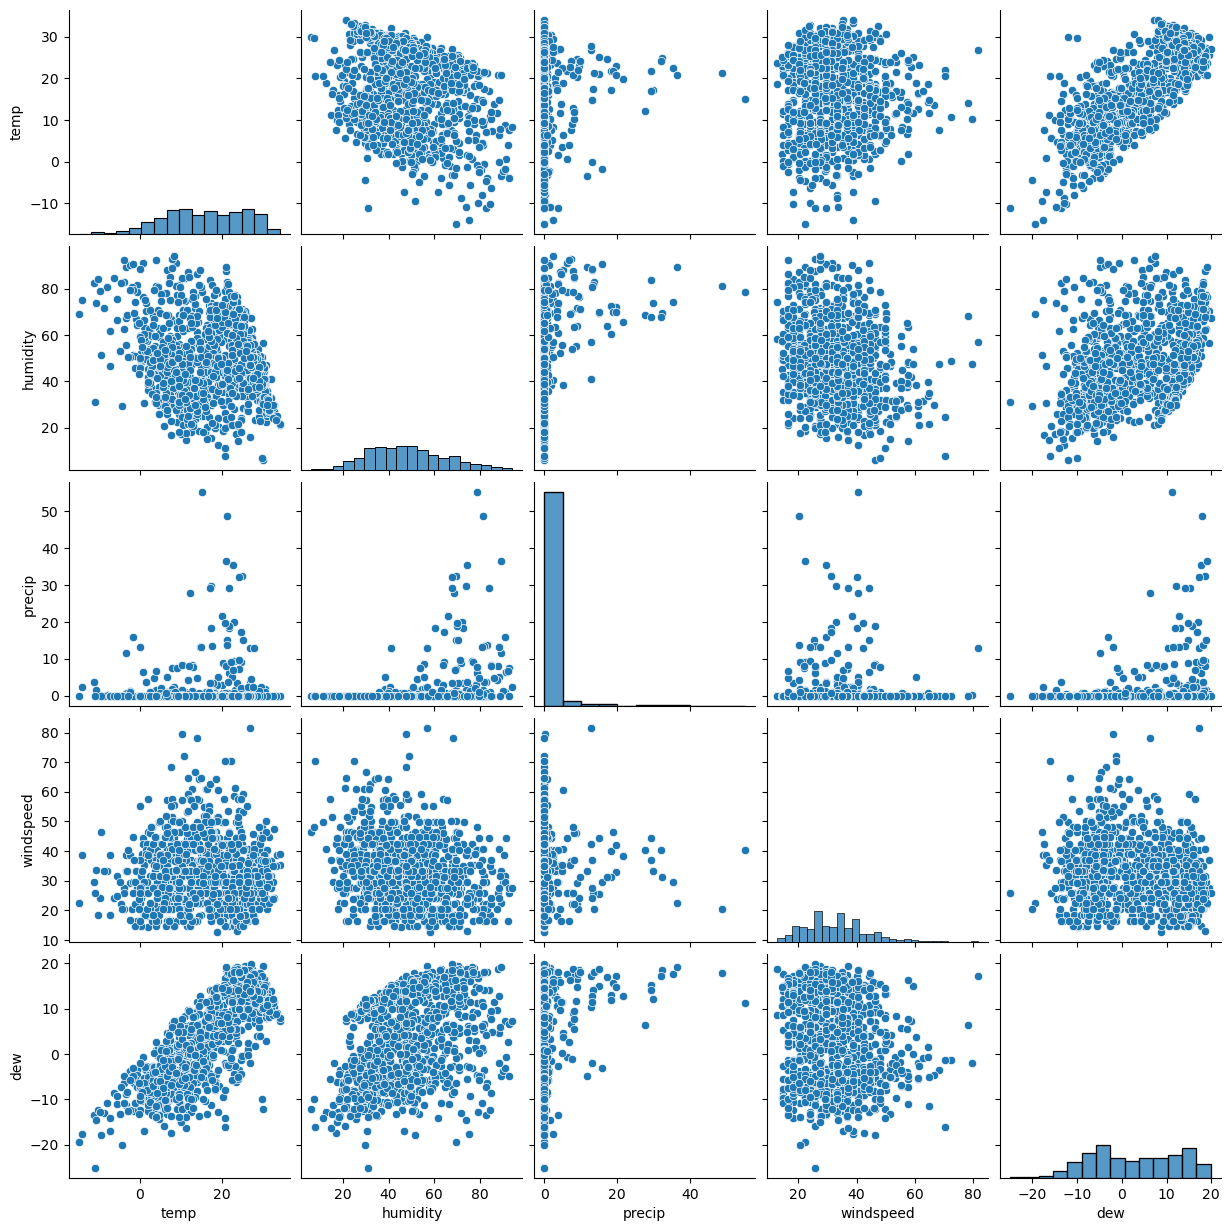

In [8]:
sns.pairplot(data[["temp",	"humidity",	"precip",	"windspeed", "dew"]])

<Axes: >

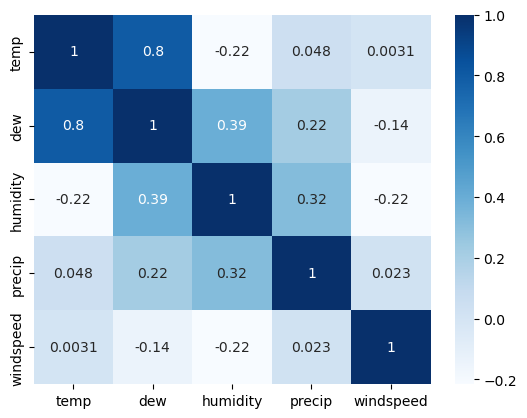

In [9]:
sns.heatmap(data.iloc[:,2:7].corr(),annot=True,cmap="Blues")

## 2. Input selection

In [10]:
X=data[["temp","humidity",	"windspeed"]]
y=data["dew"]

## 3. Train test splitting

In [11]:
# train test splitting
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,train_size=0.7)
x_train

,temp,humidity,windspeed
483,9.1,53.9,22.1
109,16.1,44.2,37.0
839,-1.4,69.7,37.0
880,10.9,39.6,48.2
203,7.5,59.0,38.8
...,...,...,...
98,16.3,64.6,40.6
49,18.3,59.1,25.7
466,16.7,48.7,40.5
13,32.6,27.4,47.5


## 4. Building model

In [12]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [13]:
poly=PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_train_poly.shape

(698, 10)

In [14]:
x_train_poly

array([[ 1.00000e+00,  9.10000e+00,  5.39000e+01, ...,  2.90521e+03,
         1.19119e+03,  4.88410e+02],
       [ 1.00000e+00,  1.61000e+01,  4.42000e+01, ...,  1.95364e+03,
         1.63540e+03,  1.36900e+03],
       [ 1.00000e+00, -1.40000e+00,  6.97000e+01, ...,  4.85809e+03,
         2.57890e+03,  1.36900e+03],
       ...,
       [ 1.00000e+00,  1.67000e+01,  4.87000e+01, ...,  2.37169e+03,
         1.97235e+03,  1.64025e+03],
       [ 1.00000e+00,  3.26000e+01,  2.74000e+01, ...,  7.50760e+02,
         1.30150e+03,  2.25625e+03],
       [ 1.00000e+00,  7.30000e+00,  4.81000e+01, ...,  2.31361e+03,
         1.32756e+03,  7.61760e+02]])

In [15]:
model=LinearRegression()
model.fit(x_train_poly,y_train)
a=model.coef_
a

array([ 0.00000000e+00,  7.74107412e-01,  5.69610599e-01,  1.15816605e-02,
        2.00057543e-03,  2.88439736e-03, -2.31557802e-03, -2.82315046e-03,
        3.83487675e-04,  1.88937749e-05])

In [16]:
y_train_pred=model.predict(x_train_poly)
#this is same as: model.intercept_+a[1]*X["humidity"]+a[2]*X["humidity"]**2

### apply on test

In [17]:
x_test_poly = poly.fit_transform(x_test)
x_test_poly.shape

(300, 10)

In [18]:
y_test_pred=model.predict(x_test_poly)

## 5. Diagnosis of the model

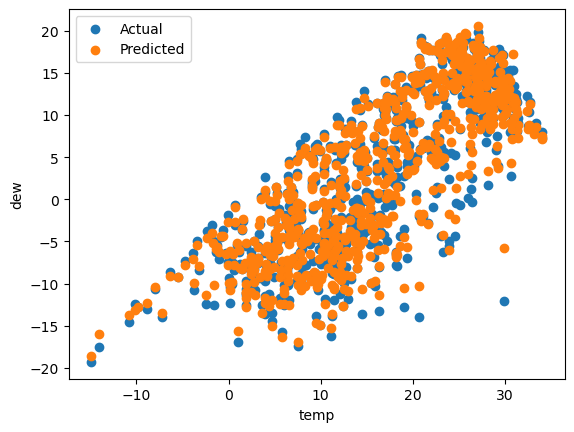

In [19]:
plt.scatter(x_train["temp"],y_train)
plt.scatter(x_train["temp"],y_train_pred)
plt.xlabel("temp")
plt.ylabel("dew")
plt.legend(["Actual","Predicted"])

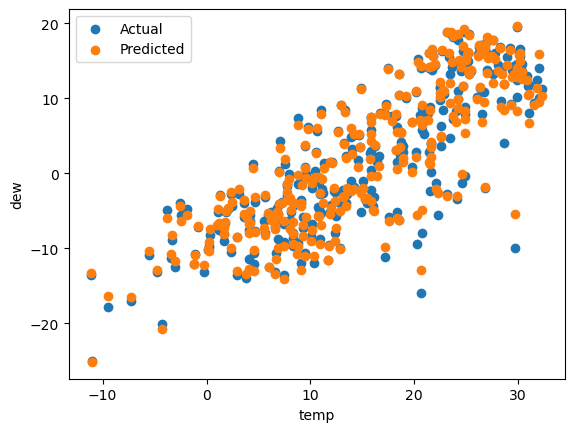

In [20]:
plt.scatter(x_test["temp"],y_test)
plt.scatter(x_test["temp"],y_test_pred)
plt.xlabel("temp")
plt.ylabel("dew")
plt.legend(["Actual","Predicted"])

In [21]:
from sklearn import metrics
trainMSE=metrics.mean_squared_error(y_train,y_train_pred)
trainRMSE=np.sqrt(trainMSE)
trainRMSE

1.0562519313281986

In [22]:
testMSE=metrics.mean_squared_error(y_test,y_test_pred)
testRMSE=np.sqrt(testMSE)
testRMSE

1.0575879412246156

## Polynomial vs linear 

In [23]:
model_lin=LinearRegression()
model_lin.fit(x_train,y_train)
y_train_pred_lin=model_lin.predict(x_train)
y_test_pred_lin=model_lin.predict(x_test)

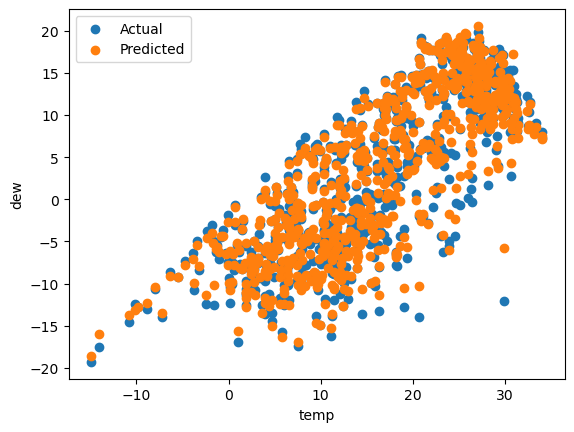

In [24]:
plt.scatter(x_train["temp"],y_train)
plt.scatter(x_train["temp"],y_train_pred)
plt.xlabel("temp")
plt.ylabel("dew")
plt.legend(["Actual","Predicted"])

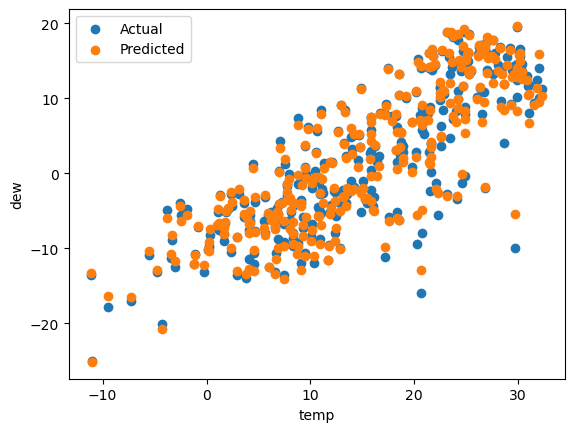

In [25]:
plt.scatter(x_test["temp"],y_test)
plt.scatter(x_test["temp"],y_test_pred)
plt.xlabel("temp")
plt.ylabel("dew")
plt.legend(["Actual","Predicted"])

In [26]:
train_linRMSE=np.sqrt(metrics.mean_squared_error(y_train,y_train_pred_lin))
train_linRMSE

1.656151736392805

In [27]:
test_linRMSE=np.sqrt(metrics.mean_squared_error(y_test,y_test_pred_lin))
test_linRMSE

1.7400517053928406